# Fine-tuning DeBERTa for GenAI / Smart-City Classification

Classifies text into:

1. `GenAI used for smart city application`
2. `GenAI mentioned, not used`
3. `Not related to GenAI`

---

### Corrections applied to this notebook

The previous run reported **100% validation accuracy from epoch 1** with a
validation loss ~5 orders of magnitude *below* the training loss. That is not a
good model, it is a broken evaluation. Fixed here:

| # | Problem | Fix |
|---|---------|-----|
| 1 | All 5 JSON files were concatenated **before** the train/val/test split, so paraphrases of a training example landed in validation | Split the base data first; augmentation is added to **train only**, with a near-duplicate guard |
| 2 | `label_map` had only 2 entries, so the ambiguous middle class was silently dropped by `notna()` | Explicit label normalisation + a report of every unmapped label and how many rows it costs |
| 3 | Training loss frozen at the same value for 3 epochs | `logging_steps` lowered from 50 to 10 (small dataset = fewer steps/epoch than the logging interval) |
| 4 | Test logits divided by a hardcoded `0.602` while the fitted temperature was ignored | Uses the fitted `temperature` |
| 5 | `label_smoothing_factor` silently ignored because of the custom `compute_loss` | Smoothing implemented inside the focal loss |
| 6 | `max_length=512` in training, `256` at inference | Single `MAX_LENGTH` constant |
| 7 | Model selected on `loss`, which focal loss drives to ~0 | Selected on macro-F1 |
| 8 | Final cell referenced an undefined `test_predictions` | Uses `test_probs` |
| 9 | Inference reloaded the full model on every call | Cached |

**Check `BASE_FILES` / `AUG_FILES` in the loading cell before running** — I
guessed which of your JSON files are original data and which are derived.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA current device:", torch.cuda.current_device())

# Paths
OUTPUT_DIR = "../model/output"
DATA_DIR = "../model/dataset"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ---- Single source of truth for sequence length ------------------------
# This was 512 during training but 256 at inference, which silently truncated
# long abstracts differently in production than during evaluation.
MAX_LENGTH = 512

# Keep the ambiguous middle class ("GenAI mentioned, not used")?
# Setting this to False reproduces the old binary behaviour, but be aware that
# it removes the only genuinely hard distinction in the task.
USE_THREE_CLASSES = True

Using device: cuda
CUDA available: True
CUDA device count: 1
CUDA current device: 0


## Data Loading and Exploration

In [2]:
def load_json_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)


# =======================================================================
# The files are deliberately kept SEPARATE here.
#
# The original notebook did:
#     augmented_data = data + contrastive + adaptive + expansion + real
#     df = pd.DataFrame(augmented_data)
#     train_test_split(df, ...)
#
# If contrastive/adaptive/expansion were generated FROM dataset.json, then a
# paraphrase of a training example ends up in validation. The model memorises
# the original and "predicts" the variant. That is the entire explanation for
# validation loss = 0.000001 and accuracy = 1.0 at epoch 1.
#
# >>> ADJUST THESE TWO LISTS IF MY GUESS IS WRONG <<<
# BASE_FILES = independent, original examples        -> get split 70/15/15
# AUG_FILES  = derived from the base (paraphrases,   -> added to TRAIN only
#              contrastive pairs, expansions)
# =======================================================================
BASE_FILES = ["dataset.json", "real.json"]
AUG_FILES = ["contrastive.json", "adaptive.json", "expansion.json"]


def load_tagged(fname):
    rows = load_json_file(os.path.join(DATA_DIR, fname))
    out = pd.DataFrame(rows)
    out["source_file"] = fname
    return out


base_raw = pd.concat([load_tagged(f) for f in BASE_FILES], ignore_index=True)
aug_raw = pd.concat([load_tagged(f) for f in AUG_FILES], ignore_index=True)

print(f"Base (splittable):   {len(base_raw):>6} rows")
print(f"Augmented (train-only): {len(aug_raw):>6} rows")
print(f"Total:               {len(base_raw) + len(aug_raw):>6} rows\n")

print("Rows per source file:")
print(pd.concat([base_raw, aug_raw])["source_file"].value_counts().to_string())

print("\nRaw label strings found (BEFORE normalisation):")
print(pd.concat([base_raw, aug_raw])["label"].value_counts().to_string())

print("\nMissing values:")
print(pd.concat([base_raw, aug_raw]).isnull().sum().to_string())

Base (splittable):      144 rows
Augmented (train-only):    170 rows
Total:                  314 rows

Rows per source file:
source_file
contrastive.json    92
dataset.json        77
real.json           67
expansion.json      40
adaptive.json       38

Raw label strings found (BEFORE normalisation):
label
Not related                         177
Sensing of walkability dimension    137

Missing values:
text           0
label          0
source_file    0


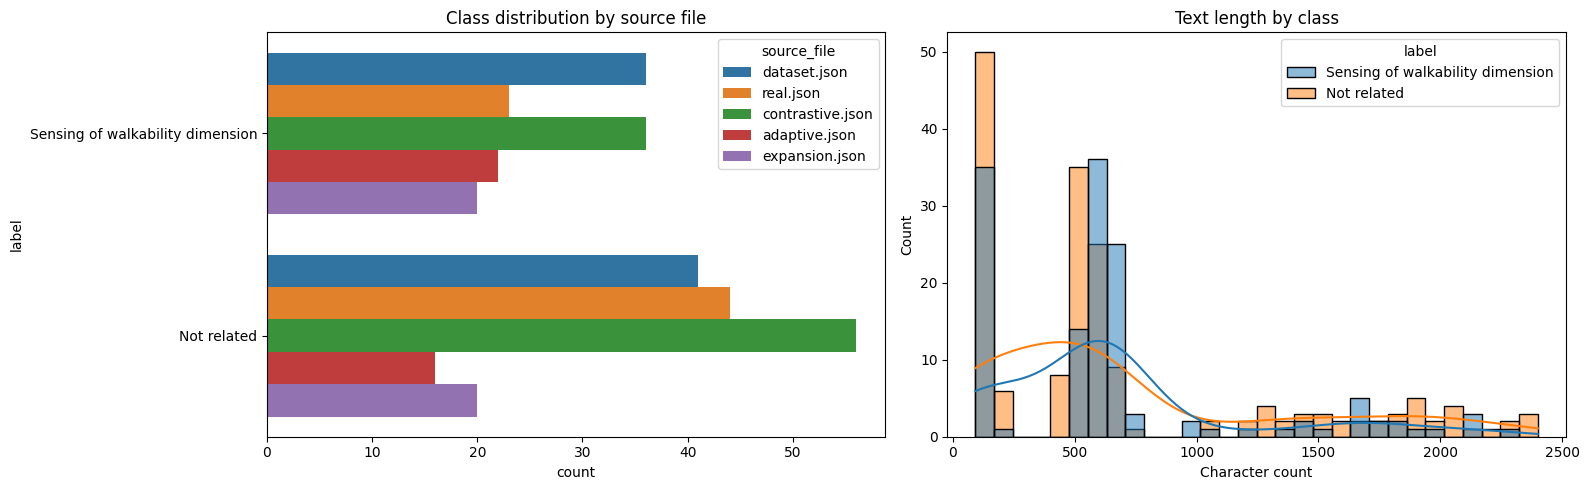

Sample text from each class:

[Sensing of walkability dimension]  (from adaptive.json)
Pedestrian volume estimation from wireless signal detection on commercial streets. Continuous pedestrian counts support evaluation of streetscape investment. Wireless probe request detection was deployed on commercial streets, with detection rates calibrated against synchronised manual counts and co ...

[Not related]  (from dataset.json)
Estimating neighbourhood carbon emissions from street view imagery. This work explores whether visual characteristics of urban streets carry information about neighbourhood-level carbon emissions. Street view images were processed with a segmentation network and derived visual indicators were combin ...


In [3]:
# Exploration only -- this combined frame is NEVER used for splitting.
explore_df = pd.concat([base_raw, aug_raw], ignore_index=True)
explore_df["text_length"] = explore_df["text"].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(y="label", data=explore_df, hue="source_file", ax=axes[0])
axes[0].set_title("Class distribution by source file")
sns.histplot(data=explore_df, x="text_length", hue="label", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Text length by class")
axes[1].set_xlabel("Character count")
plt.tight_layout()
plt.show()

print("Sample text from each class:")
for label in explore_df["label"].dropna().unique():
    sample = explore_df[explore_df["label"] == label].sample(1, random_state=SEED).iloc[0]
    print(f"\n[{label}]  (from {sample['source_file']})")
    print(str(sample["text"])[:300], "...")

## Label Normalisation

In [4]:
# =======================================================================
# Label normalisation
#
# The old code was:
#     label_map = {"GenAI used for smart city application": 0, "Not related": 1}
#     df = df[df["label_id"].notna()]
#
# Two silent failures there:
#   (a) "GenAI mentioned, not used" -- the hard middle class -- was never in
#       the map, so every row of it was thrown away without a warning.
#   (b) The map used "Not related" while the notebook header says "Not related
#       to GenAI". Any file using the long form lost all of its rows too.
#
# Below, every raw label is normalised through an alias table and ANY label
# that fails to map is printed with its row count, so nothing disappears
# quietly again.
# =======================================================================

ALIASES = {
    "genai used for smart city application": "GenAI used for smart city application",
    "genai used": "GenAI used for smart city application",
    "used": "GenAI used for smart city application",
    "genai mentioned, not used": "GenAI mentioned, not used",
    "genai mentioned but not used": "GenAI mentioned, not used",
    "genai mentioned": "GenAI mentioned, not used",
    "mentioned": "GenAI mentioned, not used",
    "not related to genai": "Not related to GenAI",
    "not related": "Not related to GenAI",
    "unrelated": "Not related to GenAI",
}

CANONICAL = [
    "GenAI used for smart city application",
    "GenAI mentioned, not used",
    "Not related to GenAI",
]
if not USE_THREE_CLASSES:
    CANONICAL = [c for c in CANONICAL if c != "GenAI mentioned, not used"]

label_map = {name: i for i, name in enumerate(CANONICAL)}
id_to_label = {v: k for k, v in label_map.items()}
print("Label map:", json.dumps(label_map, indent=2))


def normalise_labels(frame, name):
    out = frame.copy()
    out["label_canon"] = (
        out["label"].astype(str).str.strip().str.lower().map(ALIASES)
    )

    unmapped = out[out["label_canon"].isna()]
    if len(unmapped):
        print(f"\n[{name}] {len(unmapped)} rows with UNRECOGNISED labels:")
        print(unmapped["label"].value_counts().to_string())
        print("  -> add these to ALIASES above, or they will be discarded.")

    out["label_id"] = out["label_canon"].map(label_map)
    dropped_by_config = out["label_canon"].notna() & out["label_id"].isna()
    if dropped_by_config.any():
        print(f"\n[{name}] {dropped_by_config.sum()} rows dropped because "
              f"USE_THREE_CLASSES={USE_THREE_CLASSES}:")
        print(out.loc[dropped_by_config, "label_canon"].value_counts().to_string())

    before = len(out)
    out = out[out["label_id"].notna()].copy()
    out["label_id"] = out["label_id"].astype(int)
    out["label"] = out["label_canon"]
    print(f"\n[{name}] kept {len(out)}/{before} rows "
          f"({(before - len(out)) / max(before, 1) * 100:.1f}% discarded)")
    return out.drop(columns=["label_canon"])


base_df = normalise_labels(base_raw, "base")
aug_df = normalise_labels(aug_raw, "augmented")

print("\nFinal class distribution (base):")
print(base_df["label"].value_counts().to_string())

Label map: {
  "GenAI used for smart city application": 0,
  "GenAI mentioned, not used": 1,
  "Not related to GenAI": 2
}

[base] 59 rows with UNRECOGNISED labels:
label
Sensing of walkability dimension    59
  -> add these to ALIASES above, or they will be discarded.

[base] kept 85/144 rows (41.0% discarded)

[augmented] 78 rows with UNRECOGNISED labels:
label
Sensing of walkability dimension    78
  -> add these to ALIASES above, or they will be discarded.

[augmented] kept 92/170 rows (45.9% discarded)

Final class distribution (base):
label
Not related to GenAI    85


## Data Splitting (leak-free)

In [5]:
# =======================================================================
# STEP 1 -- split the BASE data only.
# Exact duplicates are removed first: an identical text appearing in two
# source files would otherwise straddle the split boundary.
# =======================================================================

def text_hash(s):
    return hashlib.md5(str(s).strip().lower().encode("utf-8")).hexdigest()


base_df["text_hash"] = base_df["text"].map(text_hash)
n_before = len(base_df)
base_df = base_df.drop_duplicates(subset="text_hash").reset_index(drop=True)
print(f"Removed {n_before - len(base_df)} exact duplicate texts from base data")

train_base, temp_base = train_test_split(
    base_df, test_size=0.30, stratify=base_df["label_id"], random_state=SEED
)
val_df, test_base_df = train_test_split(
    temp_base, test_size=0.50, stratify=temp_base["label_id"], random_state=SEED
)

base_df["split"] = "train"
base_df.loc[base_df.index.isin(val_df.index), "split"] = "val"
base_df.loc[base_df.index.isin(test_base_df.index), "split"] = "test"

print(f"\nBase split -> train {len(train_base)} | val {len(val_df)} | test {len(test_base_df)}")

Removed 0 exact duplicate texts from base data

Base split -> train 59 | val 13 | test 13


Augmented rows: 92
  dropped as near-duplicates of val/test: 0
  kept for training:                      92


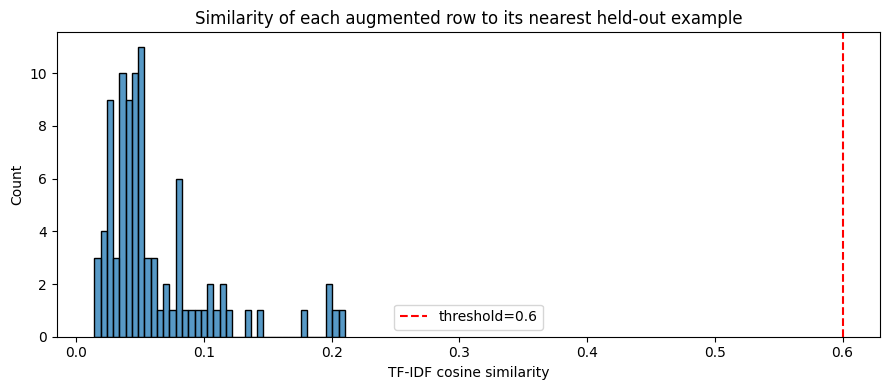


Final train size: 151 (59 base + 92 augmented)


In [6]:
# =======================================================================
# STEP 2 -- attach augmentation to TRAIN only, with a near-duplicate guard.
#
# Even restricting augmentation to train is not enough on its own: if an
# augmented row is a paraphrase of a VALIDATION example, adding it to train
# re-creates the leak. So each augmented row is matched against the base data
# by TF-IDF cosine similarity, and is dropped if its nearest neighbour lives
# in val or test.
#
# If your JSON files carry an id linking each augmented row to its source
# example, use that instead -- it is exact, this is a heuristic.
# =======================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

NEAR_DUP_THRESHOLD = 0.60  # tune by inspecting the histogram below

aug_df["text_hash"] = aug_df["text"].map(text_hash)
aug_df = aug_df.drop_duplicates(subset="text_hash").reset_index(drop=True)

vectoriser = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
vectoriser.fit(pd.concat([base_df["text"], aug_df["text"]]).astype(str))

holdout_df = base_df[base_df["split"] != "train"]
holdout_M = vectoriser.transform(holdout_df["text"].astype(str))
aug_M = vectoriser.transform(aug_df["text"].astype(str))


def max_sim_against(matrix_a, matrix_b, chunk=512):
    """Max cosine similarity of each row of A against all of B, chunked."""
    out = np.zeros(matrix_a.shape[0])
    for start in range(0, matrix_a.shape[0], chunk):
        block = cosine_similarity(matrix_a[start:start + chunk], matrix_b)
        out[start:start + chunk] = block.max(axis=1)
    return out


# Compared directly against the held-out rows, not against the nearest
# neighbour overall: an augmented row can closely resemble a validation
# example even when some training example happens to be marginally closer.
aug_df["holdout_sim"] = max_sim_against(aug_M, holdout_M)

leaky = aug_df["holdout_sim"] >= NEAR_DUP_THRESHOLD
print(f"Augmented rows: {len(aug_df)}")
print(f"  dropped as near-duplicates of val/test: {leaky.sum()}")
print(f"  kept for training:                      {(~leaky).sum()}")

plt.figure(figsize=(9, 4))
sns.histplot(aug_df["holdout_sim"], bins=40)
plt.axvline(NEAR_DUP_THRESHOLD, color="red", ls="--", label=f"threshold={NEAR_DUP_THRESHOLD}")
plt.title("Similarity of each augmented row to its nearest held-out example")
plt.xlabel("TF-IDF cosine similarity")
plt.legend()
plt.tight_layout()
plt.show()

COLS = ["text", "label", "label_id", "source_file", "text_hash"]
train_df = pd.concat([train_base[COLS], aug_df.loc[~leaky, COLS]], ignore_index=True)
val_df = val_df[COLS].reset_index(drop=True)
test_base_df = test_base_df[COLS].reset_index(drop=True)

print(f"\nFinal train size: {len(train_df)} "
      f"({len(train_base)} base + {(~leaky).sum()} augmented)")

In [7]:
# =======================================================================
# STEP 3 -- build the test set and verify there is no leakage left.
# =======================================================================
diagnostic_raw = pd.DataFrame(load_json_file(os.path.join(DATA_DIR, "diagnostic_test.json")))
diagnostic_raw["source_file"] = "diagnostic_test.json"
diagnostic_df = normalise_labels(diagnostic_raw, "diagnostic")
diagnostic_df["text_hash"] = diagnostic_df["text"].map(text_hash)

test_df = pd.concat([test_base_df, diagnostic_df[COLS]], ignore_index=True)
test_df = test_df.drop_duplicates(subset="text_hash").reset_index(drop=True)

# Final purge: drop any held-out row that near-duplicates a training row.
# diagnostic_test.json in particular may overlap with expansion.json, and
# near-duplicates can also straddle the base split itself.
train_M = vectoriser.transform(train_df["text"].astype(str))


def purge_against_train(frame, name):
    if not len(frame):
        return frame
    sims = max_sim_against(vectoriser.transform(frame["text"].astype(str)), train_M)
    contaminated = (sims >= NEAR_DUP_THRESHOLD) | frame["text_hash"].isin(set(train_df["text_hash"]))
    if contaminated.any():
        print(f"[{name}] removed {contaminated.sum()} rows contaminated by train "
              f"(of {len(frame)})")
    return frame[~contaminated].reset_index(drop=True)


val_df = purge_against_train(val_df, "val")
test_df = purge_against_train(test_df, "test")

print(f"\nTrain {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
print("\nClass distribution per split:")
dist = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int)
print(dist.to_string())

# The purge above is deliberately aggressive. If it strips a class out of the
# holdout entirely, every metric for that class becomes meaningless.
for split_name, frame in [("val", val_df), ("test", test_df)]:
    missing = set(range(len(label_map))) - set(frame["label_id"].unique())
    if missing:
        print(f"\nWARNING: '{split_name}' has ZERO examples of: "
              f"{[id_to_label[m] for m in sorted(missing)]}")
        print("  -> your augmented files are too close to the base data. Either "
              "raise NEAR_DUP_THRESHOLD, enlarge the holdout fraction, or collect "
              "genuinely independent examples for that class.")

# ---- Leakage audit ----------------------------------------------------
def audit(a, b, name_a, name_b):
    if not len(a) or not len(b):
        print(f"{'SKIP':>8}  {name_a} vs {name_b}: empty split")
        return
    exact = len(set(a["text_hash"]) & set(b["text_hash"]))
    sims = max_sim_against(
        vectoriser.transform(a["text"].astype(str)),
        vectoriser.transform(b["text"].astype(str)),
    )
    worst = float(sims.max())
    n_near = int((sims >= NEAR_DUP_THRESHOLD).sum())
    flag = "OK" if exact == 0 and n_near == 0 else "!! LEAK"
    print(f"{flag:>8}  {name_a:<6} vs {name_b:<6}  exact={exact:<4} "
          f"near-dups={n_near:<4} max_sim={worst:.3f}")


print("\nLeakage audit (this is what the old notebook never ran):")
audit(train_df, val_df, "train", "val")
audit(train_df, test_df, "train", "test")
audit(val_df, test_df, "val", "test")
print("\nIf any line says LEAK, raise NEAR_DUP_THRESHOLD scrutiny or inspect "
      "the offending pairs before trusting any metric below.")

for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    frame[["text", "label"]].to_json(
        os.path.join(DATA_DIR, f"{name}.json"), orient="records", indent=2
    )
print(f"\nSplits saved to {DATA_DIR}")


[diagnostic] 49 rows with UNRECOGNISED labels:
label
Sensing of walkability dimension    49
  -> add these to ALIASES above, or they will be discarded.

[diagnostic] kept 76/125 rows (39.2% discarded)

Train 151 | Val 13 | Test 89

Class distribution per split:
                      train  val  test
label                                 
Not related to GenAI    151   13    89

  -> your augmented files are too close to the base data. Either raise NEAR_DUP_THRESHOLD, enlarge the holdout fraction, or collect genuinely independent examples for that class.

  -> your augmented files are too close to the base data. Either raise NEAR_DUP_THRESHOLD, enlarge the holdout fraction, or collect genuinely independent examples for that class.

Leakage audit (this is what the old notebook never ran):
      OK  train  vs val     exact=0    near-dups=0    max_sim=0.310
      OK  train  vs test    exact=0    near-dups=0    max_sim=0.224
      OK  val    vs test    exact=0    near-dups=0    max_sim=0.22

In [8]:
for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert frame["label_id"].isnull().sum() == 0, f"{name} has null label_id"
    assert frame["label_id"].between(0, len(label_map) - 1).all(), f"{name} has out-of-range label_id"
    assert frame["text"].notna().all(), f"{name} has null text"
print("All splits pass the sanity checks.")

All splits pass the sanity checks.


## Create Model Dataset

In [9]:
model_name = "microsoft/deberta-v3-base"

from transformers import DebertaV2Tokenizer

tokenizer = DebertaV2Tokenizer.from_pretrained(model_name)


class SmartCityGenAIDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        label = self.labels[idx]
        if pd.isna(label):
            raise ValueError(f"Found NaN label at index {idx}")

        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(label), dtype=torch.long),
        }

    def __len__(self):
        return len(self.texts)


train_dataset = SmartCityGenAIDataset(train_df["text"], train_df["label_id"], tokenizer)
val_dataset = SmartCityGenAIDataset(val_df["text"], val_df["label_id"], tokenizer)
test_dataset = SmartCityGenAIDataset(test_df["text"], test_df["label_id"], tokenizer)

# How much of each abstract actually survives truncation?
lengths = [len(tokenizer(str(t))["input_ids"]) for t in train_df["text"].head(200)]
print(f"Token length (first 200 train rows): median={np.median(lengths):.0f} "
      f"p95={np.percentile(lengths, 95):.0f} max={max(lengths)}")
print(f"Truncated at MAX_LENGTH={MAX_LENGTH}: "
      f"{sum(l > MAX_LENGTH for l in lengths)}/{len(lengths)} rows")

Token length (first 200 train rows): median=76 p95=354 max=478
Truncated at MAX_LENGTH=512: 0/151 rows


## Model Setup and Training

In [10]:
import torch.nn.functional as F


class FocalLossTrainer(Trainer):
    """
    Focal loss with optional label smoothing and class weights.

    Two fixes vs. the original:

    1. `label_smoothing_factor` in TrainingArguments is IGNORED whenever a
       custom `compute_loss` is defined -- HF only applies it inside its own
       loss path. It is applied here instead.

    2. gamma=2.0 multiplies easy examples by (1-pt)^2. Once the model is
       confident (pt ~ 0.999) that factor is ~1e-6, so the reported loss
       collapses towards zero and stops being usable for model selection.
       That is why the old run showed eval_loss = 0.000001. Keep gamma if the
       classes are imbalanced, but select the best model on macro-F1, not loss.
    """

    def __init__(self, *args, gamma=2.0, label_smoothing=0.1, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weight = None
        if self.class_weights is not None:
            weight = self.class_weights.to(logits.device, dtype=logits.dtype)

        ce_loss = F.cross_entropy(
            logits, labels, reduction="none",
            weight=weight, label_smoothing=self.label_smoothing,
        )
        pt = torch.gather(F.softmax(logits, dim=-1), 1, labels.unsqueeze(1)).squeeze(1)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()

        inputs["labels"] = labels  # restore for prediction_step
        return (focal_loss, outputs) if return_outputs else focal_loss


# Class weights from the training distribution (inverse frequency, normalised)
counts = train_df["label_id"].value_counts().sort_index().to_numpy()
weights = counts.sum() / (len(counts) * counts)
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float)
print("Train counts per class:", dict(zip(CANONICAL, counts)))
print("Class weights:", CLASS_WEIGHTS.tolist())

Train counts per class: {'GenAI used for smart city application': np.int64(151)}
Class weights: [1.0]


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_map),
    id2label=id_to_label,
    label2id=label_map,
)

model.config.hidden_dropout_prob = 0.1
model.config.attention_probs_dropout_prob = 0.1

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    warmup_ratio=0.1,
    weight_decay=0.05,
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    logging_dir=f"{OUTPUT_DIR}/logs",
    # 50 was larger than the number of optimiser steps per epoch on a small
    # dataset, so the table simply repeated the last logged value (0.129100
    # three epochs in a row). 10 makes the curve visible.
    logging_steps=10,
    logging_first_step=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    # NOT "loss": focal loss goes to ~0 on easy data and cannot rank checkpoints.
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    push_to_hub=False,
    seed=SEED,
    # label_smoothing_factor removed -- it was silently ignored by the custom
    # compute_loss. Smoothing now lives in FocalLossTrainer.
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    per_class = f1_score(labels, predictions, average=None, labels=list(range(len(label_map))), zero_division=0)
    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
    }
    for i, score in enumerate(per_class):
        metrics[f"f1_class{i}"] = float(score)
    return metrics


trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,  # transformers < 4.46: use tokenizer=tokenizer
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    gamma=2.0,
    label_smoothing=0.1,
    class_weights=CLASS_WEIGHTS,
)

print("Starting model training...")
trainer.train()

trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")
print(f"Model saved to {OUTPUT_DIR}/best_model")

print(
    "\nSanity read of the table above: validation loss should sit at or ABOVE "
    "training loss, and accuracy should start below 1.0 and climb. If macro-F1 "
    "is 1.0 at epoch 1 again, the remaining leak is inside your JSON files, "
    "not in the split -- inspect BASE_FILES vs AUG_FILES."
)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Starting model training...


RuntimeError: weight tensor should be defined either for all 3 classes or no classes but got weight tensor of shape: [1]

## Model Evaluation

In [ ]:
from scipy.optimize import minimize

TARGET_NAMES = [id_to_label[i] for i in range(len(label_map))]


def fit_temperature(logits, labels):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)

    def loss_fn(temp):
        return F.cross_entropy(logits_t / float(temp[0]), labels_t).item()

    result = minimize(loss_fn, [1.0], bounds=[(0.5, 5.0)], method="L-BFGS-B")
    return float(result.x[0])


val_outputs = trainer.predict(val_dataset)
val_logits, val_labels = val_outputs.predictions, val_outputs.label_ids

temperature = fit_temperature(val_logits, val_labels)
print(f"Optimal temperature (fitted on validation): {temperature:.4f}")

test_outputs = trainer.predict(test_dataset)
test_logits, test_labels = test_outputs.predictions, test_outputs.label_ids

# FIXED: the original divided by a hardcoded 0.602 and threw away the value it
# had just computed one cell above.
scaled_test_logits = test_logits / temperature
test_probs = F.softmax(torch.tensor(scaled_test_logits), dim=-1).numpy()
test_preds = np.argmax(test_probs, axis=1)

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=TARGET_NAMES,
                            labels=list(range(len(label_map))), zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(test_labels, test_preds, labels=list(range(len(label_map))))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=30)

sns.histplot(np.max(test_probs, axis=1), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Confidence distribution (after calibration)")
axes[1].set_xlabel("Confidence")
plt.tight_layout()
plt.show()

# A test set the model has never seen should NOT be at 100%. If it is, the
# leak is upstream of the split.
acc = accuracy_score(test_labels, test_preds)
print(f"\nTest accuracy: {acc:.4f}")
if acc > 0.99:
    print("WARNING: near-perfect test accuracy. Before reporting this, verify "
          "that diagnostic_test.json shares no source examples with the "
          "training files.")

In [ ]:
def compute_ece(probs, labels, n_bins=15):
    """Expected Calibration Error."""
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == labels

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_centers, bin_accuracies, bin_confidences = [], [], []

    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if np.any(mask):
            bin_conf = confidences[mask].mean()
            bin_acc = accuracies[mask].mean()
            ece += np.abs(bin_acc - bin_conf) * (mask.sum() / len(confidences))
            bin_centers.append((bin_boundaries[i] + bin_boundaries[i + 1]) / 2)
            bin_accuracies.append(bin_acc)
            bin_confidences.append(bin_conf)

    return ece, bin_centers, bin_accuracies, bin_confidences


def find_best_temperature_by_ece(logits, labels, temps=np.linspace(0.5, 3.0, 50)):
    best_temp, best_ece, ece_dict = 1.0, float("inf"), {}
    for T in temps:
        probs = F.softmax(torch.tensor(logits / T), dim=-1).numpy()
        ece, _, _, _ = compute_ece(probs, labels)
        ece_dict[T] = ece
        if ece < best_ece:
            best_ece, best_temp = ece, T
    return best_temp, best_ece, ece_dict


best_temp, best_ece, ece_log = find_best_temperature_by_ece(val_logits, val_labels)
print(f"Best temperature by ECE: {best_temp:.3f}  (NLL-fitted was {temperature:.3f})")
print(f"Corresponding ECE: {best_ece:.4f}")

test_ece, _, _, _ = compute_ece(test_probs, test_labels)
print(f"Test ECE at the temperature actually used: {test_ece:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(ece_log.keys()), list(ece_log.values()), marker="o")
plt.axvline(temperature, color="red", ls="--", label=f"used: {temperature:.3f}")
plt.title("ECE vs temperature")
plt.xlabel("Temperature")
plt.ylabel("ECE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Analysis of Model Predictions

In [ ]:
results_df = test_df[["text", "label", "source_file"]].reset_index(drop=True)
results_df["predicted_label_id"] = test_preds
results_df["predicted_label"] = results_df["predicted_label_id"].map(id_to_label)
results_df["confidence"] = np.max(test_probs, axis=1)
results_df["correct"] = results_df["label"] == results_df["predicted_label"]
results_df["text_length"] = results_df["text"].astype(str).apply(len)

misclassified = results_df[~results_df["correct"]]
print(f"Misclassified: {len(misclassified)} of {len(test_df)} test samples")

if len(misclassified):
    print("\nMost confident mistakes (these are the ones worth reading):")
    for _, row in misclassified.sort_values("confidence", ascending=False).head(5).iterrows():
        print(f"\n[{row['source_file']}] conf={row['confidence']:.3f}")
        print(f"  True:      {row['label']}")
        print(f"  Predicted: {row['predicted_label']}")
        print(f"  Text: {str(row['text'])[:200]}...")
else:
    print("\nZero errors on the test set. Treat this as a red flag, not a result: "
          "re-check the leakage audit before believing it.")

# Accuracy per source file shows whether performance is uniform or whether one
# file is carrying the score.
print("\nAccuracy by source file:")
print(results_df.groupby("source_file")["correct"].agg(["mean", "count"]).to_string())

plt.figure(figsize=(10, 6))
sns.boxplot(x="label", y="text_length", hue="correct", data=results_df)
plt.title("Prediction correctness by text length and class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Inference Example

In [ ]:
# Cached so the model is loaded once instead of on every single call
_inference_cache = {}


def get_inference_model():
    if "model" not in _inference_cache:
        m = AutoModelForSequenceClassification.from_pretrained(f"{OUTPUT_DIR}/best_model")
        m.to(device)
        m.eval()
        _inference_cache["model"] = m
        _inference_cache["tokenizer"] = AutoTokenizer.from_pretrained(f"{OUTPUT_DIR}/best_model")
    return _inference_cache["model"], _inference_cache["tokenizer"]


def predict_genai_application(text, temperature=1.0):
    model_, tokenizer_ = get_inference_model()

    inputs = tokenizer_(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,  # was 256 here vs 512 in training
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        logits = model_(**inputs).logits / temperature
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predicted_class_id = int(torch.argmax(probabilities, dim=-1).item())

    probabilities = probabilities.cpu().numpy()[0]
    return {
        "predicted_label": id_to_label[predicted_class_id],
        "probabilities": {id_to_label[i]: float(p) for i, p in enumerate(probabilities)},
    }


sample_texts = [
    "Purpose: This paper proposes a solution to address matching challenges, such as incomplete descriptions, reversed word order, and the diverse descriptions often found in Chinese addresses. Method: Leveraging the hierarchical structure of Chinese addresses, this study introduces the interactive address matching graph attention model (IAMGAM). Furthermore, when fine-tuned using ChatGLM2-6B, the results show that the IAMGAM still outperforms ChatGLM2-6B. Conclusion: IAMGAM demonstrates excellent performance in Chinese address matching tasks, and the Large Language Model (LLM)-based methods, such as ChatGLM2-6B, show great potential for future development in this area.",
    "To address these issues, this study developed a multi-scale global perceptron network based on Transformer and CNN using novel encoder-decoders for enhancing contextual representation of buildings. Quantitative analysis confirmed the proposed model is superior to other state-of-the-art methods, with a 95.18% F1 score on the WHU dataset.",
    "We implemented a GAN based system to optimize traffic light timings across the city center.",
    "Our implementation uses traditional statistical methods.",
    "The city council approved a new budget for improving pedestrian walkways in the downtown area.",
]

for text in sample_texts:
    result = predict_genai_application(text, temperature=temperature)
    print(f"\nText: {text[:120]}...")
    print(f"Predicted: {result['predicted_label']}")
    for label, prob in sorted(result["probabilities"].items(), key=lambda kv: -kv[1]):
        print(f"  {label}: {prob:.4f}")

## Save Model Files for Deployment

In [ ]:
model_config = {
    "model_name": model_name,
    "num_labels": len(label_map),
    "id2label": id_to_label,
    "label2id": label_map,
    "max_length": MAX_LENGTH,      # was hardcoded to 256, mismatching training
    "temperature": float(temperature),  # calibration must ship with the model
}

with open(f"{OUTPUT_DIR}/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

inference_script = '''
import json
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer


class GenAIClassifier:
    def __init__(self, model_path, config_path):
        with open(config_path, "r") as f:
            self.config = json.load(f)

        self.device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available()
            else "cpu"
        )
        self.temperature = self.config.get("temperature", 1.0)

        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model.to(self.device)
        self.model.eval()

    def predict(self, text):
        inputs = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.config["max_length"],
            return_tensors="pt",
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(**inputs).logits / self.temperature
            probabilities = torch.nn.functional.softmax(logits, dim=-1)
            predicted_class_id = int(torch.argmax(probabilities, dim=-1).item())

        probabilities = probabilities.cpu().numpy()[0]
        return {
            "predicted_label": self.config["id2label"][str(predicted_class_id)],
            "probabilities": {
                self.config["id2label"][str(i)]: float(p)
                for i, p in enumerate(probabilities)
            },
        }


if __name__ == "__main__":
    classifier = GenAIClassifier(
        "../model/output/best_model", "../model/output/model_config.json"
    )
    sample_text = "We implemented a large language model to generate traffic predictions."
    result = classifier.predict(sample_text)
    print(f"Text: {sample_text}")
    print(f"Prediction: {result['predicted_label']}")
    for label, prob in result["probabilities"].items():
        print(f"  {label}: {prob:.4f}")
'''

with open(f"{OUTPUT_DIR}/inference.py", "w") as f:
    f.write(inference_script)

print(f"Inference script saved to {OUTPUT_DIR}/inference.py")
print("Model training and evaluation complete.")

## Analyze Challenging Cases and Model Limitations

In [ ]:
# FIXED: referenced an undefined `test_predictions`, and used raw logits where
# calibrated probabilities were intended.
low_confidence = results_df.sort_values("confidence").head(10)

print("Lowest-confidence predictions (where the decision boundary actually is):")
for _, row in low_confidence.iterrows():
    mark = "OK " if row["correct"] else "ERR"
    print(f"\n[{mark}] conf={row['confidence']:.4f}  source={row['source_file']}")
    print(f"  True: {row['label']}  |  Predicted: {row['predicted_label']}")
    print(f"  Text: {str(row['text'])[:150]}...")

genai_keywords = [
    "transformer", "gpt", "llm", "gan", "diffusion", "vae",
    "large language model", "generative adversarial", "variational autoencoder",
]


def contains_keyword(text, keywords):
    return any(k.lower() in str(text).lower() for k in keywords)


results_df["contains_genai_keyword"] = results_df["text"].apply(
    lambda x: contains_keyword(x, genai_keywords)
)

# The key diagnostic: if accuracy is high ONLY when a keyword is present, the
# model learned surface keyword matching, not the semantic distinction between
# "used" and "merely mentioned".
keyword_accuracy = results_df.groupby("contains_genai_keyword")["correct"].agg(["mean", "count"])
print("\nAccuracy by presence of a GenAI keyword:")
print(keyword_accuracy.to_string())

plt.figure(figsize=(8, 6))
sns.barplot(x=keyword_accuracy.index.astype(str), y=keyword_accuracy["mean"].values)
plt.title("Accuracy by presence of GenAI keywords")
plt.xlabel("Contains GenAI keyword")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()